# Exercises: Potential Outcomes Framework

These exercises reinforce concepts from the **Potential Outcomes** notebook.

---

## Instructions

- Work through each exercise sequentially
- Use the hints if you get stuck
- Try to complete each exercise before looking at the solutions
- Solutions are in a separate notebook: `potential_outcomes_solutions.ipynb`

---

## Setup

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style and random seed
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print("Setup complete!")

---

## Exercise 1: Reverse Selection Bias

**Difficulty**: Easy

**Problem**: Modify the selection mechanism so that people with **low Y(0)** (low baseline earnings) are MORE likely to receive treatment instead of high Y(0). This might happen if a job training program targets people who need help the most.

**Tasks**:
1. Generate data with 100 people where Y(0) ~ N(35, 5) and treatment effect is constant at 5
2. Make treatment probability **decrease** as Y(0) increases (opposite of the notebook)
3. Calculate the naive estimate and compare to true ATE
4. Does the naive estimator over-estimate or under-estimate? Why?

**Learning Goal**: Understand that selection bias can go in either direction depending on the selection mechanism.

### Hints

<details>
<summary>Click for Hint 1</summary>

To make low Y(0) people more likely to be treated, use a negative coefficient in the logistic function:

```python
prob_treatment = 1 / (1 + np.exp(+Y0_normalized))  # Note the + instead of -
```
</details>

<details>
<summary>Click for Hint 2</summary>

Calculate:
- E[Y|T=1] - mean outcome for treated
- E[Y|T=0] - mean outcome for control
- Naive estimate = E[Y|T=1] - E[Y|T=0]
- Compare to true ATE = 5
</details>

<details>
<summary>Click for Hint 3</summary>

Check the baseline difference:
- E[Y(0)|T=1] - E[Y(0)|T=0]
- If negative, treated group has lower baseline → underestimation
</details>

### Your Solution

In [ ]:
# Exercise 1: Your code here

# Step 1: Generate data
n = 100
ATE = 5.0
# TODO: Generate Y0 from normal distribution
# TODO: Create Y1 = Y0 + 5 (constant treatment effect)
Y0 = np.random.normal(45, 5, n)
Y1 = Y0 + 5  # Constant treatment effect of 5

# Step 2: Create reverse selection bias
# TODO: Make low Y0 more likely to be treated
# Treatment probability increases with baseline earnings
# Logistic function: P(T=1) depends on Y(0)
Y0_normalized = (Y0 - Y0.mean()) / Y0.std()
prob_treatment = 1 / (1 + np.exp(+Y0_normalized))
T = np.random.binomial(1, p=prob_treatment, size=n)

# Step 3: Calculate naive estimate
# TODO: Compute E[Y|T=1] - E[Y|T=0]
Y_observed = np.where(T == 1, Y1, Y0)
naive_estimate = Y_observed[T == 1].mean() - Y_observed[T == 0].mean()

baseline_diff = Y0[T == 1].mean() - Y0[T == 0].mean()

# Step 4: Compare to true ATE
# TODO: Print results and explain over/under estimation
print(f"Naive Estimate: {naive_estimate:.2f}")
print(f"True ATE: {ATE:.2f}")
print(f"Bias: ${naive_estimate - ATE:.2f}k")
print(f"Baseline difference in Y(0) between treated and control: {baseline_diff:.2f}")

if naive_estimate < ATE:
    print(f"\n⚠️ The naive estimator UNDERESTIMATES the treatment effect!")
    print(f"This is because treated people would have earned LESS even without training.")
    print(f"Low earners were more likely to get treatment, pulling down the treated group average.")
else:
    print(f"\nNaive estimator overestimates (or approximately unbiased due to sampling variation).")

---

## Exercise 2: Sample Size and Precision

**Difficulty**: Easy

**Problem**: In the main notebook, we ran 1000 experiments with n=100 people each. What happens if we use smaller samples?

**Tasks**:
1. Modify the simulation to use n=20 instead of n=100
2. Run 1000 experiments with random assignment
3. Plot the distribution of estimates
4. Compare the standard deviation (precision) to the n=100 case
5. What happens to the bias? What happens to the variance?

**Learning Goal**: Understand the difference between bias (systematic error) and variance (random error), and how sample size affects them.

### Hints

<details>
<summary>Click for Hint 1</summary>

Copy the `simulate_experiment` function from the main notebook or write your own:

```python
def simulate_experiment(n, true_ate):
    Y0 = np.random.normal(35, 5, n)
    effects = np.random.normal(true_ate, 1, n)
    Y1 = Y0 + effects
    T = np.random.binomial(1, 0.5, n)
    Y_obs = np.where(T == 1, Y1, Y0)
    return Y_obs[T == 1].mean() - Y_obs[T == 0].mean()
```
</details>

<details>
<summary>Click for Hint 2</summary>

Run experiments:
```python
estimates_small = [simulate_experiment(20, 5.0) for _ in range(1000)]
estimates_large = [simulate_experiment(100, 5.0) for _ in range(1000)]
```
</details>

<details>
<summary>Click for Hint 3</summary>

Key insight:
- Bias = mean(estimates) - true_ATE (should be ~0 for both)
- Variance = std(estimates) (should be LARGER for n=20)
- Randomization eliminates bias regardless of sample size
- But smaller samples have more variance (less precision)
</details>

### Your Solution

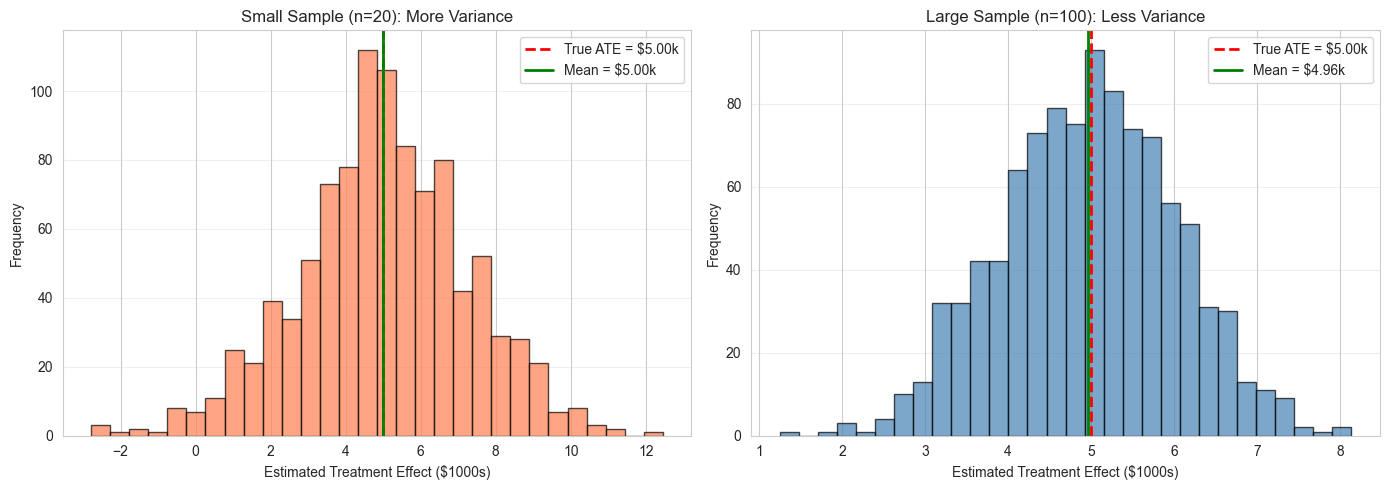

Small Sample (n=20) - Mean: 5.00, Std: 2.25
Large Sample (n=100) - Mean: 4.96, Std: 1.05


In [7]:
# Exercise 2: Your code here

# Step 1: Define simulation function
# TODO: Write simulate_experiment function
def simulate_experiment(n, true_ate):
    """Simulate a randomized experiment."""
    Y0 = np.random.normal(35, 5, n)
    effects = np.random.normal(true_ate, 1, n)
    Y1 = Y0 + effects
    
    # Random assignment
    T = np.random.binomial(1, 0.5, n)
    
    # Observed outcomes
    Y_obs = np.where(T == 1, Y1, Y0)
    
    # Naive estimate
    estimate = Y_obs[T == 1].mean() - Y_obs[T == 0].mean()
    return estimate

# Step 2: Run experiments with different sample sizes
# TODO: Run 1000 experiments with n=20
# TODO: Run 1000 experiments with n=100
n_experiments = 1000
estimates_n20 = [simulate_experiment(20, ATE) for _ in range(n_experiments)]
estimates_n100 = [simulate_experiment(100, ATE) for _ in range(n_experiments)]
estimates_n20 = np.array(estimates_n20)
estimates_n100 = np.array(estimates_n100)

# Step 3: Visualize distributions
# TODO: Create histogram comparing both distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Small sample
axes[0].hist(estimates_n20, bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[0].axvline(ATE, color='red', linestyle='--', linewidth=2, label=f'True ATE = ${ATE:.2f}k')
axes[0].axvline(estimates_n20.mean(), color='green', linestyle='-', linewidth=2,
                label=f'Mean = ${estimates_n20.mean():.2f}k')
axes[0].set_xlabel('Estimated Treatment Effect ($1000s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Small Sample (n=20): More Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Large sample
axes[1].hist(estimates_n100, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].axvline(ATE, color='red', linestyle='--', linewidth=2, label=f'True ATE = ${ATE:.2f}k')
axes[1].axvline(estimates_n100.mean(), color='green', linestyle='-', linewidth=2,
                label=f'Mean = ${estimates_n100.mean():.2f}k')
axes[1].set_xlabel('Estimated Treatment Effect ($1000s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Large Sample (n=100): Less Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Step 4: Calculate statistics
# TODO: Print mean and std for both
print(f"Small Sample (n=20) - Mean: {estimates_n20.mean():.2f}, Std: {estimates_n20.std():.2f}")
print(f"Large Sample (n=100) - Mean: {estimates_n100.mean():.2f}, Std: {estimates_n100.std():.2f}")

# TODO: Discuss bias vs variance

---

## Exercise 3: Heterogeneous Treatment Effects with Negatives

**Difficulty**: Medium

**Problem**: Create a scenario where treatment helps some people but hurts others. For example, an intensive job training program might help low-skilled workers but actually reduce earnings for high-skilled workers (opportunity cost of time).

**Tasks**:
1. Generate 200 people with varying skill levels (use a skill variable)
2. Make treatment effect depend on skill: positive for low skill, negative for high skill
3. Calculate the overall ATE - is it positive or negative?
4. Simulate a scenario where only people with **positive** individual effects select into treatment
5. What is the naive estimate? What is the ATT? What is the ATU?

**Learning Goal**: Understand heterogeneous treatment effects, and that ATE can mask important variation. Also learn the difference between ATE, ATT, and ATU.

### Hints

<details>
<summary>Click for Hint 1</summary>

Create skill-dependent effects:
```python
skill = np.random.normal(0, 1, 200)  # Standardized skill
treatment_effect = 10 - 5 * skill  # High skill → negative effect
# When skill = -1: effect = 15 (helps low-skill)
# When skill = +1: effect = 5 (helps less)
# When skill = +2: effect = 0 (no effect)
# When skill = +3: effect = -5 (hurts high-skill)
```
</details>

<details>
<summary>Click for Hint 2</summary>

Make only people who benefit select into treatment:
```python
# People "know" their treatment effect and only enroll if positive
T = (treatment_effect > 0).astype(int)
```
</details>

<details>
<summary>Click for Hint 3</summary>

Calculate different estimands:
- ATE = treatment_effect.mean() (all people)
- ATT = treatment_effect[T == 1].mean() (only treated)
- ATU = treatment_effect[T == 0].mean() (only untreated)
</details>

### Your Solution

Overall ATE (all people): $10.20k

Treatment Effect Distribution:
  Minimum: $-3.60k (hurts high-skill people)
  Maximum: $23.10k (helps low-skill people)
  % with positive effect: 98.5%
  % with negative effect: 1.5%

Selection Mechanism: Only people with positive effects enroll
  % treated: 98.5%
  % untreated: 1.5%
ATE: $10.20k
ATT: $10.39k
ATU: $-2.29k
Naive Estimate: $-12.49k


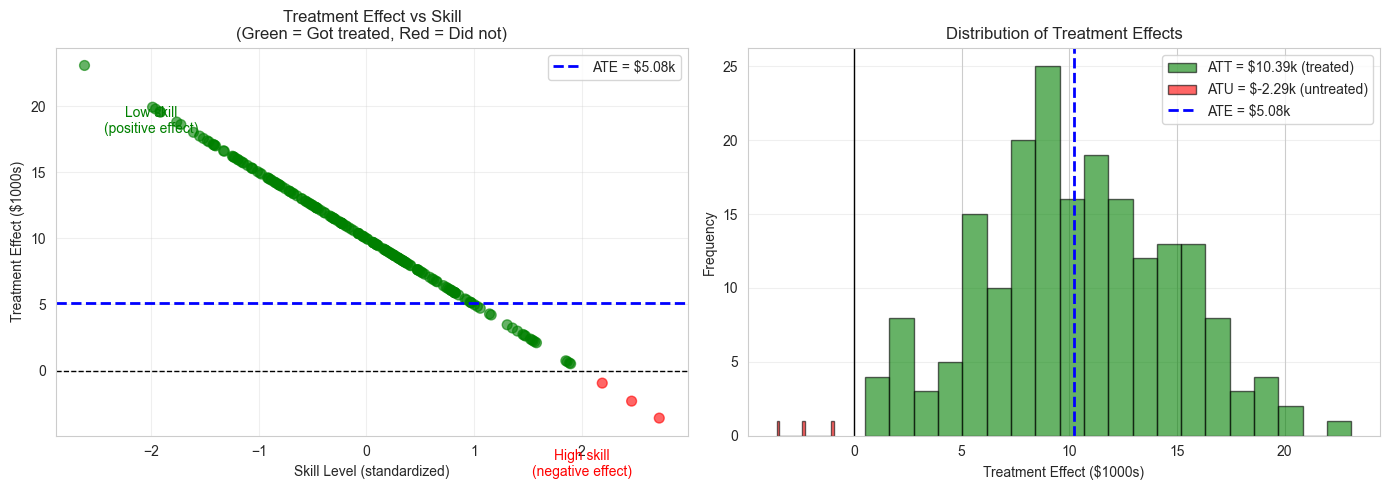

In [11]:
# Exercise 3: Your code here
np.random.seed(42)

# Step 1: Generate heterogeneous data
# TODO: Create skill variable
# TODO: Make treatment effect depend on skill: helps low-skill but hurts high-skill
n = 200
skill = np.random.normal(0, 1, n)  # Standardized skill variable
Y0 = 40 + 10 * skill + np.random.normal(0, 5, n)  # Baseline earnings depend on skill
treatment_effect = 10 - 5 * skill  # Helps low-skill but hurts high-skill
Y1 = Y0 + treatment_effect

# Step 2: Calculate overall ATE
# TODO: What is the average effect?
overall_ate = treatment_effect.mean()
print(f"Overall ATE (all people): ${overall_ate:.2f}k")
print(f"\nTreatment Effect Distribution:")
print(f"  Minimum: ${treatment_effect.min():.2f}k (hurts high-skill people)")
print(f"  Maximum: ${treatment_effect.max():.2f}k (helps low-skill people)")
print(f"  % with positive effect: {(treatment_effect > 0).mean() * 100:.1f}%")
print(f"  % with negative effect: {(treatment_effect < 0).mean() * 100:.1f}%")

# Step 3: Selection based on individual effects
# TODO: Only people who benefit get treated
T = (treatment_effect > 0).astype(int)  # Only those with positive effect get treated
print(f"\nSelection Mechanism: Only people with positive effects enroll")
print(f"  % treated: {T.mean() * 100:.1f}%")
print(f"  % untreated: {(1 - T.mean()) * 100:.1f}%")

# Step 4: Calculate estimands
# TODO: Compute ATE, ATT, ATU
# TODO: Compute naive estimate
Y_obs = np.where(T == 1, Y1, Y0)
ATT = treatment_effect[T == 1].mean()  # Effect for treated
ATU = treatment_effect[T == 0].mean()  # Effect for untreated
naive_estimate = Y_obs[T == 1].mean() - Y_obs[T == 0].mean()


print(f"ATE: ${overall_ate:.2f}k")
print(f"ATT: ${ATT:.2f}k")
print(f"ATU: ${ATU:.2f}k")
print(f"Naive Estimate: ${naive_estimate:.2f}k")

# Step 5: Visualize
# TODO: Plot treatment effect vs skill
# TODO: Show who got treated
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Treatment effect vs skill
colors = ['green' if t == 1 else 'red' for t in T]
axes[0].scatter(skill, treatment_effect, c=colors, alpha=0.6, s=50)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].axhline(ATE, color='blue', linestyle='--', linewidth=2, label=f'ATE = ${ATE:.2f}k')
axes[0].set_xlabel('Skill Level (standardized)')
axes[0].set_ylabel('Treatment Effect ($1000s)')
axes[0].set_title('Treatment Effect vs Skill\n(Green = Got treated, Red = Did not)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add text annotations
axes[0].text(-2, 18, 'Low skill\n(positive effect)', ha='center', fontsize=10, color='green')
axes[0].text(2, -8, 'High skill\n(negative effect)', ha='center', fontsize=10, color='red')

# Right: Distribution comparison
axes[1].hist(treatment_effect[T == 1], bins=20, alpha=0.6, color='green', 
             label=f'ATT = ${ATT:.2f}k (treated)', edgecolor='black')
axes[1].hist(treatment_effect[T == 0], bins=20, alpha=0.6, color='red', 
             label=f'ATU = ${ATU:.2f}k (untreated)', edgecolor='black')
axes[1].axvline(overall_ate, color='blue', linestyle='--', linewidth=2, label=f'ATE = ${ATE:.2f}k')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Treatment Effect ($1000s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Treatment Effects')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## Exercise 4: Three Treatment Levels

**Difficulty**: Medium-Hard

**Problem**: Extend the potential outcomes framework to **three** treatments: T ∈ {0, 1, 2}. For example:
- T=0: No training
- T=1: Basic training (2 weeks)
- T=2: Advanced training (6 weeks)

**Tasks**:
1. For each person, generate three potential outcomes: Y(0), Y(1), Y(2)
2. How many potential outcomes does each person have?
3. How many pairwise treatment effects can you calculate per person?
4. Calculate three pairwise ATEs: E[Y(1)-Y(0)], E[Y(2)-Y(0)], E[Y(2)-Y(1)]
5. Randomly assign people to T=0, T=1, or T=2 (equal probability)
6. Can you recover all three pairwise ATEs from the data?

**Learning Goal**: Understand that the framework extends to multiple treatments, and the complexity grows with the number of treatment levels.

### Hints

<details>
<summary>Click for Hint 1</summary>

For 3 treatments, each person has 3 potential outcomes:
- Y(0): Outcome under no training
- Y(1): Outcome under basic training  
- Y(2): Outcome under advanced training

Pairwise comparisons: 3 choose 2 = 3 pairs:
1. Y(1) - Y(0): Basic vs None
2. Y(2) - Y(0): Advanced vs None  
3. Y(2) - Y(1): Advanced vs Basic
</details>

<details>
<summary>Click for Hint 2</summary>

Generate potential outcomes:
```python
Y0 = np.random.normal(35, 5, n)
Y1 = Y0 + np.random.normal(3, 1, n)  # Basic adds ~3k
Y2 = Y0 + np.random.normal(7, 1, n)  # Advanced adds ~7k
```
</details>

<details>
<summary>Click for Hint 3</summary>

Randomly assign to 3 groups:
```python
T = np.random.choice([0, 1, 2], size=n, p=[1/3, 1/3, 1/3])
```

Observe outcomes:
```python
Y_obs = np.where(T == 0, Y0, np.where(T == 1, Y1, Y2))
```
</details>

<details>
<summary>Click for Hint 4</summary>

Estimate pairwise ATEs:
```python
# Basic vs None
ATE_1_0 = Y_obs[T == 1].mean() - Y_obs[T == 0].mean()

# Advanced vs None
ATE_2_0 = Y_obs[T == 2].mean() - Y_obs[T == 0].mean()

# Advanced vs Basic
ATE_2_1 = Y_obs[T == 2].mean() - Y_obs[T == 1].mean()
```
</details>

### Your Solution

In [12]:
# Exercise 4: Your code here

# Solution to Exercise 4
np.random.seed(42)

# Step 1: Generate three potential outcomes
n = 300
Y0 = np.random.normal(35, 5, n)  # No training
Y1 = Y0 + np.random.normal(3, 1, n)  # Basic training (2 weeks)
Y2 = Y0 + np.random.normal(7, 1.5, n)  # Advanced training (6 weeks)

# Step 2: Count potential outcomes and comparisons
print("POTENTIAL OUTCOMES WITH 3 TREATMENTS:\n")
print(f"Number of potential outcomes per person: 3")
print(f"  Y(0): No training")
print(f"  Y(1): Basic training")
print(f"  Y(2): Advanced training")

print(f"\nNumber of pairwise comparisons: 3")
print(f"  1. Y(1) - Y(0): Basic vs None")
print(f"  2. Y(2) - Y(0): Advanced vs None")
print(f"  3. Y(2) - Y(1): Advanced vs Basic")

# Step 3: Calculate true pairwise ATEs
true_ATE_1_0 = (Y1 - Y0).mean()  # Basic vs None
true_ATE_2_0 = (Y2 - Y0).mean()  # Advanced vs None
true_ATE_2_1 = (Y2 - Y1).mean()  # Advanced vs Basic

print(f"\nTRUE PAIRWISE ATEs:")
print(f"  E[Y(1) - Y(0)] = ${true_ATE_1_0:.2f}k (Basic vs None)")
print(f"  E[Y(2) - Y(0)] = ${true_ATE_2_0:.2f}k (Advanced vs None)")
print(f"  E[Y(2) - Y(1)] = ${true_ATE_2_1:.2f}k (Advanced vs Basic)")

# Verify transitivity
print(f"\nTransitivity check: ATE(2,0) = ATE(2,1) + ATE(1,0)")
print(f"  ${true_ATE_2_0:.2f}k ≈ ${true_ATE_2_1:.2f}k + ${true_ATE_1_0:.2f}k = ${true_ATE_2_1 + true_ATE_1_0:.2f}k ✓")

# Step 4: Randomly assign treatment
T = np.random.choice([0, 1, 2], size=n, p=[1/3, 1/3, 1/3])

# Observe outcomes
Y_obs = np.where(T == 0, Y0, np.where(T == 1, Y1, Y2))

print(f"\nTREATMENT ASSIGNMENT:")
print(f"  % in T=0 (None):     {(T == 0).mean() * 100:.1f}%")
print(f"  % in T=1 (Basic):    {(T == 1).mean() * 100:.1f}%")
print(f"  % in T=2 (Advanced): {(T == 2).mean() * 100:.1f}%")

# Step 5: Estimate pairwise ATEs from data
est_ATE_1_0 = Y_obs[T == 1].mean() - Y_obs[T == 0].mean()
est_ATE_2_0 = Y_obs[T == 2].mean() - Y_obs[T == 0].mean()
est_ATE_2_1 = Y_obs[T == 2].mean() - Y_obs[T == 1].mean()

print(f"\nESTIMATED PAIRWISE ATEs (from observed data):")
print(f"  Est[Y(1) - Y(0)] = ${est_ATE_1_0:.2f}k  (True: ${true_ATE_1_0:.2f}k)")
print(f"  Est[Y(2) - Y(0)] = ${est_ATE_2_0:.2f}k  (True: ${true_ATE_2_0:.2f}k)")
print(f"  Est[Y(2) - Y(1)] = ${est_ATE_2_1:.2f}k  (True: ${true_ATE_2_1:.2f}k)")

print(f"\n✓ All three pairwise ATEs can be recovered from randomized data!")
print(f"   (Small differences due to sampling variation)")

POTENTIAL OUTCOMES WITH 3 TREATMENTS:

Number of potential outcomes per person: 3
  Y(0): No training
  Y(1): Basic training
  Y(2): Advanced training

Number of pairwise comparisons: 3
  1. Y(1) - Y(0): Basic vs None
  2. Y(2) - Y(0): Advanced vs None
  3. Y(2) - Y(1): Advanced vs Basic

TRUE PAIRWISE ATEs:
  E[Y(1) - Y(0)] = $2.98k (Basic vs None)
  E[Y(2) - Y(0)] = $7.12k (Advanced vs None)
  E[Y(2) - Y(1)] = $4.14k (Advanced vs Basic)

Transitivity check: ATE(2,0) = ATE(2,1) + ATE(1,0)
  $7.12k ≈ $4.14k + $2.98k = $7.12k ✓

TREATMENT ASSIGNMENT:
  % in T=0 (None):     33.7%
  % in T=1 (Basic):    31.7%
  % in T=2 (Advanced): 34.7%

ESTIMATED PAIRWISE ATEs (from observed data):
  Est[Y(1) - Y(0)] = $3.39k  (True: $2.98k)
  Est[Y(2) - Y(0)] = $7.68k  (True: $7.12k)
  Est[Y(2) - Y(1)] = $4.30k  (True: $4.14k)

✓ All three pairwise ATEs can be recovered from randomized data!
   (Small differences due to sampling variation)


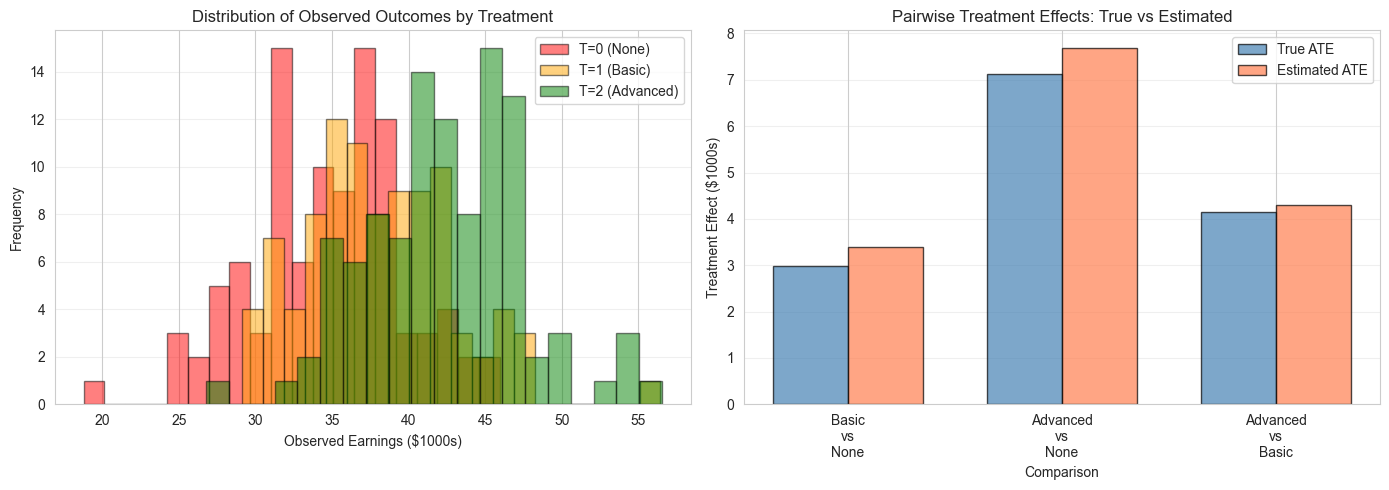

In [13]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distribution by treatment group
for t, label, color in [(0, 'T=0 (None)', 'red'), 
                         (1, 'T=1 (Basic)', 'orange'), 
                         (2, 'T=2 (Advanced)', 'green')]:
    axes[0].hist(Y_obs[T == t], bins=20, alpha=0.5, label=label, 
                 color=color, edgecolor='black')
axes[0].set_xlabel('Observed Earnings ($1000s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Observed Outcomes by Treatment')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Right: Estimated vs True ATEs
comparisons = ['Basic\nvs\nNone', 'Advanced\nvs\nNone', 'Advanced\nvs\nBasic']
true_ates = [true_ATE_1_0, true_ATE_2_0, true_ATE_2_1]
est_ates = [est_ATE_1_0, est_ATE_2_0, est_ATE_2_1]

x_pos = np.arange(len(comparisons))
width = 0.35

axes[1].bar(x_pos - width/2, true_ates, width, label='True ATE', 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[1].bar(x_pos + width/2, est_ates, width, label='Estimated ATE', 
            color='coral', alpha=0.7, edgecolor='black')

axes[1].set_xlabel('Comparison')
axes[1].set_ylabel('Treatment Effect ($1000s)')
axes[1].set_title('Pairwise Treatment Effects: True vs Estimated')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparisons)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## Next Steps

Once you've completed these exercises:
1. Check your solutions against `potential_outcomes_solutions.ipynb`
2. Experiment with different parameters and scenarios
3. Think about how these concepts apply to your own work
4. Move on to the next notebook: [DAGs Basics](../03_dags_basics.ipynb)

---

**Good luck!** 🚀